In [82]:
import sys
sys.path.append('../..')

import canopus
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from plotnine import *
from qiskit import QuantumCircuit
import seaborn as sns

# plt.rcParams['font.family'] = 'Times New Roman'
sns.set_context('paper', font_scale=1.5)

color = sns.color_palette("Set2", 4).as_hex()[-1]
colors = [color, color]

In [83]:
sns.color_palette("Set2", 4)

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.9058823529411765, 0.5411764705882353, 0.7647058823529411)]

### Runtime analysis

In [2]:
from qiskit.circuit.library import QuantumVolume
SEED = 1997
depth = 200
qc =  QuantumVolume(20, depth, seed=SEED, flatten=True)
qc = canopus.rebase_to_canonical(qc)


canopus.utils.print_circ_info(qc)

/var/folders/r5/1qhftv4d3_g432jmyr9vy6wc0000gn/T/ipykernel_49593/155791816.py:4: DeprecationWarning: The class ``qiskit.circuit.library.quantum_volume.QuantumVolume`` is deprecated as of Qiskit 2.2. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.quantum_volume instead.


+------------+-----------+--------------+-------+----------+
| num_qubits | num_gates | num_2q_gates | depth | depth_2q |
+------------+-----------+--------------+-------+----------+
|     20     |    5693   |     1891     |  401  |   200    |
+------------+-----------+--------------+-------+----------+


In [3]:
depths = [50, 100, 150, 200]
runtime_qv_10 = np.load('runtime_quantum_volume_10.npy')
runtime_qv_15 = np.load('runtime_quantum_volume_15.npy')
runtime_qv_20 = np.load('runtime_quantum_volume_20.npy')

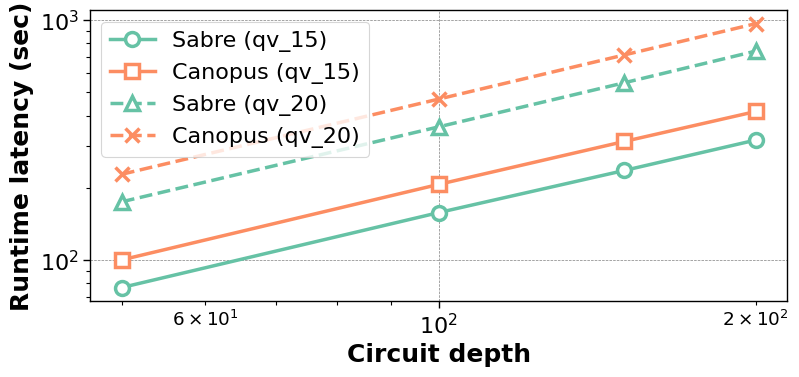

In [8]:
plt.figure(figsize=(8.25, 4))

# plt.plot(depths, runtime_qv_15[0], 'o-', label='Sabre (qv_15)', markersize=10, color='lightblue', markerfacecolor='white', markeredgewidth=2.5, linewidth=2.5)
# plt.plot(depths, runtime_qv_15[1], 's-', label='Canopus (qv_15)', markersize=10, color='lightcoral', markerfacecolor='white', markeredgewidth=2.5, linewidth=2.5)
# plt.plot(depths, runtime_qv_20[0], 'o--', label='Sabre (qv_20)', markersize=10, color='royalblue', markerfacecolor='white', markeredgewidth=2.5, linewidth=2.5)
# plt.plot(depths, runtime_qv_20[1], 's--', label='Canopus (qv_20)', markersize=10, color='crimson', markerfacecolor='white', markeredgewidth=2.5, linewidth=2.5)
plt.plot(depths, runtime_qv_15[0], 'o-', label='Sabre (qv_15)', markersize=10, color=colors[0], markerfacecolor='white', markeredgewidth=2.5, linewidth=2.5)
plt.plot(depths, runtime_qv_15[1], 's-', label='Canopus (qv_15)', markersize=10, color=colors[1], markerfacecolor='white', markeredgewidth=2.5, linewidth=2.5)
plt.plot(depths, runtime_qv_20[0], '^--', label='Sabre (qv_20)', markersize=10, color=colors[0],    markerfacecolor='white', markeredgewidth=2.5, linewidth=2.5)
plt.plot(depths, runtime_qv_20[1], 'x--', label='Canopus (qv_20)', markersize=10, color=colors[1], markerfacecolor='white', markeredgewidth=2.5, linewidth=2.5)
plt.legend(fontsize=16)
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.xticks(depths, fontsize=16)
plt.yticks(fontsize=16)
plt.yscale('log')
plt.xscale('log')
plt.ylabel('Runtime latency (sec)', fontsize=18, fontweight='bold')
plt.xlabel('Circuit depth', fontsize=18, fontweight='bold')

plt.tight_layout()

plt.savefig('../figures/runtime.pdf')
plt.show()

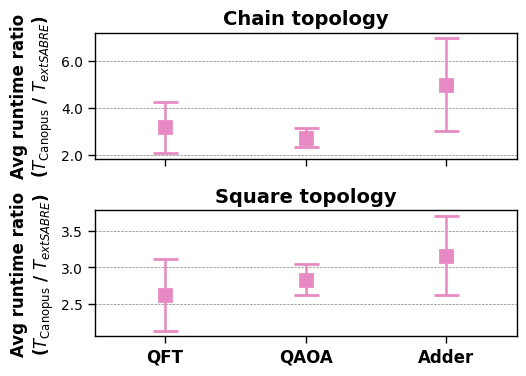

PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `runtime_scalability_ratio.pdf'.


In [121]:
df_qft = pd.read_csv('runtime_scalability_qft.csv')
ratio_chain_qft = df_qft[df_qft['topology'] == 'chain']['ratio']
ratio_square_qft = df_qft[df_qft['topology'] == 'square']['ratio']

df_qaoa = pd.read_csv('runtime_scalability_qaoa.csv')
ratio_chain_qaoa = df_qaoa[df_qaoa['topology'] == 'chain']['ratio']
ratio_square_qaoa = df_qaoa[df_qaoa['topology'] == 'square']['ratio']

df_adder = pd.read_csv('runtime_scalability_adder.csv')
ratio_chain_adder = df_adder[df_adder['topology'] == 'chain']['ratio']
ratio_square_adder = df_adder[df_adder['topology'] == 'square']['ratio']

# ── plot ──────────────────────────────────────────────────────────────────────
labels = ['QFT', 'QAOA', 'Adder']
x = np.arange(len(labels))

chain_means  = [ratio_chain_qft.mean(),  ratio_chain_qaoa.mean(),  ratio_chain_adder.mean()]
chain_stds   = [ratio_chain_qft.std(),   ratio_chain_qaoa.std(),   ratio_chain_adder.std()]
square_means = [ratio_square_qft.mean(), ratio_square_qaoa.mean(), ratio_square_adder.mean()]
square_stds  = [ratio_square_qft.std(),  ratio_square_qaoa.std(),  ratio_square_adder.std()]

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(5.5, 4), sharex=True)


labels = ['QFT', 'QAOA', 'Adder']
x = np.arange(len(labels))  # [0, 1, 2]

def _draw_panel(ax, means, stds, color, title):
    ax.errorbar(x, means, yerr=stds,
                fmt='s', markersize=9, capsize=9, capthick=1.5,
                color=color, markeredgewidth=2, # ecolor='grey',
                linewidth=1.8, label='Canopus / SABRE')

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontweight='bold', fontsize=12)

    # 1) ytick 数字号变小
    ax.tick_params(axis='y', labelsize=10)

    ax.set_ylabel('Avg runtime ratio\n($T_{\\text{Canopus}}$ / $T_{\
\text{SABRE}}$)', fontsize=12, fontweight='bold')
    from matplotlib.ticker import FormatStrFormatter
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(axis='y', color='gray', linestyle='--', linewidth=0.5)

_draw_panel(ax_top, chain_means,  chain_stds, colors[0], 'Chain topology')
_draw_panel(ax_bot, square_means, square_stds, colors[1], 'Square topology')

for ax in (ax_top, ax_bot):
    ax.set_xlim(-0.5, 2.5)   # 范围加大，点会显得更紧凑

plt.tight_layout()
plt.savefig('./runtime_scalability_ratio.pdf')
plt.show()

!pdfcrop runtime_scalability_ratio.pdf runtime_scalability_ratio.pdf

In [97]:
from scipy.stats import gmean

latency = np.concatenate((runtime_qv_20[1] / runtime_qv_20[0], runtime_qv_15[1] / runtime_qv_15[0]))
m = gmean(latency)
m

1.3085314665074472

In [101]:
100 * ((latency - m) / m)

array([-0.45670795, -0.21798428, -0.1672838 , -0.52526077, -0.31772655,
        0.19367429,  0.97266296,  0.52821778])

In [102]:
latency

array([1.3025553 , 1.30567907, 1.30634251, 1.30165826, 1.30437391,
       1.31106576, 1.32125907, 1.31544336])

In [92]:
print(runtime_qv_15[1] / runtime_qv_15[0])
print(runtime_qv_20[1] / runtime_qv_20[0])

[1.30437391 1.31106576 1.32125907 1.31544336]
[1.3025553  1.30567907 1.30634251 1.30165826]


In [103]:
slope0 = (runtime_qv_15[0][-1] - runtime_qv_15[0][0]) / (depths[-1] - depths[0])
slope1 = (runtime_qv_15[1][-1] - runtime_qv_15[1][0]) / (depths[-1] - depths[0])

slope1 / slope0

1.3189899715421962

In [104]:
slope0 = (runtime_qv_20[0][-1] - runtime_qv_20[0][0]) / (depths[-1] - depths[0])
slope1 = (runtime_qv_20[1][-1] - runtime_qv_20[1][0]) / (depths[-1] - depths[0])

slope1 / slope0

1.301382269620117

In [40]:
np.mean(runtime_rand_20[0] / runtime_rand_10[0]), np.mean(runtime_rand_20[1] / runtime_rand_10[1])

(5.551752316341062, 5.682644381020092)

In [41]:
np.mean(runtime_qv_20[0] / runtime_qv_10[0]), np.mean(runtime_qv_20[1] / runtime_qv_10[1])

(6.4371080930122755, 6.230938059817996)